# Ensemble Methods for Regression
In this notebook, we will demonstrate how to use ensemble methods for regression using the **Random Forest Regressor** and **Gradient Boosting Regressor**. We will also explore combining these models using the **Voting Regressor** and **Stacking Regressor**.

### Step 1: Load and Preprocess the Dataset
We'll load the **California Housing Prices** dataset and preprocess it for regression tasks.

In [3]:
import pandas as pd
import gdown
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, VotingRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt


In [5]:
# Load the dataset 

file_id = "1A-ANU_Reo1edbe-eQ6mX4VukMYTDLMgA"
url = f"https://drive.google.com/uc?id={file_id}"
gdown.download(url, "creditcard.csv", quiet=False)

housingdata = pd.read_csv("creditcard.csv")
housingdata.head()

housingdata.head()

Downloading...
From: https://drive.google.com/uc?id=1A-ANU_Reo1edbe-eQ6mX4VukMYTDLMgA
To: /home/langstkip/workspace/myOUK_Masters/MLS-SEM2/CSA821/creditcard.csv
100%|██████████| 814k/814k [00:00<00:00, 1.35MB/s]


,longitude,latitude,housingMedianAge,totalRooms,totalBedrooms,population,households,medianIncome,medianHouseValue
0,-114.31,34.19,15,5612,1283,1015,472,1.4936,66900
1,-114.47,34.40,19,7650,1901,1129,463,1.8200,80100
2,-114.56,33.69,17,720,174,333,117,1.6509,85700
3,-114.57,33.64,14,1501,337,515,226,3.1917,73400
4,-114.57,33.57,20,1454,326,624,262,1.9250,65500


### Step 2: Select Features and Target
We will separate the features (X) and the target (y), and then split the data into training and testing sets.

In [14]:
# Select features (X) and target (y)
X = housingdata.drop(columns=['medianHouseValue'])
y = housingdata['medianHouseValue']

In [15]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [16]:
# Standardize the feature data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Step 3: Train Base Models (Random Forest & Gradient Boosting)
We'll now apply **Random Forest Regressor** and **Gradient Boosting Regressor** individually.

In [17]:
# Initialize the base regressors
rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42)
gb_regressor = GradientBoostingRegressor(n_estimators=100, random_state=42)

In [18]:
# Train the base models
rf_regressor.fit(X_train_scaled, y_train)
gb_regressor.fit(X_train_scaled, y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft 

In [19]:
# Predict using the base models
y_pred_rf = rf_regressor.predict(X_test_scaled)
y_pred_gb = gb_regressor.predict(X_test_scaled)

In [20]:
# Evaluate the base models using Mean Squared Error
mse_rf = mean_squared_error(y_test, y_pred_rf)
mse_gb = mean_squared_error(y_test, y_pred_gb)

In [21]:
print(f'Random Forest MSE: {mse_rf:.4f}')
print(f'Gradient Boosting MSE: {mse_gb:.4f}')

Random Forest MSE: 2434964783.6812
Gradient Boosting MSE: 2960108244.5863


### Step 4: Combine Models Using Voting Regressor
Now we combine the predictions of the **Random Forest** and **Gradient Boosting** regressors using a **Voting Regressor**.

In [22]:
# Combine the models using a Voting Regressor
ensemble_model = VotingRegressor(estimators=[('rf', rf_regressor), ('gb', gb_regressor)])

In [23]:
# Train the ensemble model
ensemble_model.fit(X_train_scaled, y_train)

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingRegressor`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('rf', ...), ('gb', ...)]"
,"weights weights: array-like of shape (n_regressors,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted values before averaging. Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_feature

In [24]:
# Make predictions using the ensemble model
y_pred_ensemble = ensemble_model.predict(X_test_scaled)

In [25]:
# Evaluate the ensemble model using Mean Squared Error
mse_ensemble = mean_squared_error(y_test, y_pred_ensemble)

In [26]:
print(f'Ensemble Model (Voting Regressor) MSE: {mse_ensemble:.4f}')

Ensemble Model (Voting Regressor) MSE: 2496233594.2496


### Step 5: Compare the Results
Let's compare the **Mean Squared Error (MSE)** values of the individual models and the ensemble model.

In [27]:
# Print the MSE of individual models and the ensemble model
print('\nModel Performance Comparison:')
print(f'Random Forest MSE: {mse_rf:.4f}')
print(f'Gradient Boosting MSE: {mse_gb:.4f}')
print(f'Ensemble (Voting) Model MSE: {mse_ensemble:.4f}')


Model Performance Comparison:
Random Forest MSE: 2434964783.6812
Gradient Boosting MSE: 2960108244.5863
Ensemble (Voting) Model MSE: 2496233594.2496


### Step 6: Visualize the Results
Let's visualize the predicted vs actual values for the ensemble model.

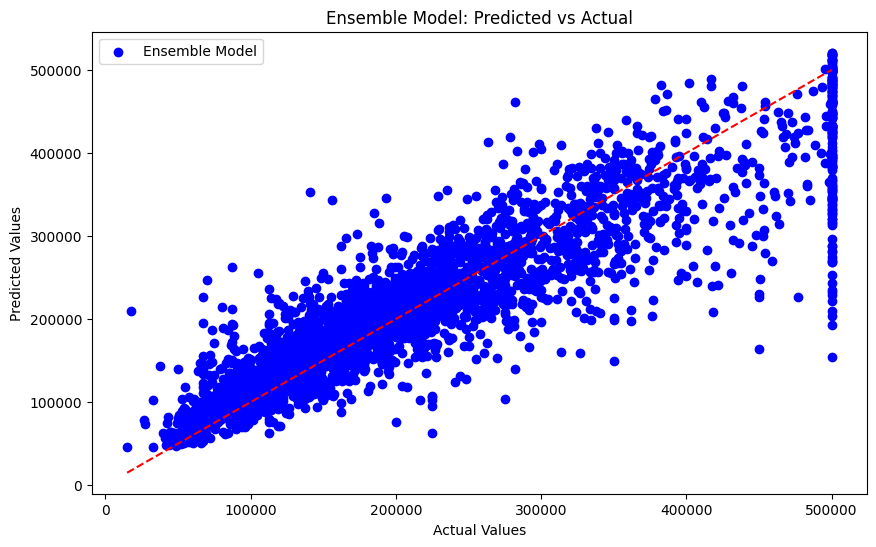

In [28]:
# Plotting the predicted vs actual values for the ensemble model
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred_ensemble, color='blue', label='Ensemble Model')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Ensemble Model: Predicted vs Actual')
plt.legend()
plt.show()

### Step 7: Alternative Ensemble Method - Stacking Regressor
We can also try a **Stacking Regressor** which combines the base models using another model (e.g., Linear Regression) to make final predictions.

In [29]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import LinearRegression

In [30]:
# Create the base models for stacking
estimators = [
    ('rf', rf_regressor),
    ('gb', gb_regressor)
]

In [31]:
# Create the stacking regressor using a linear regression as the final estimator
stacking_model = StackingRegressor(estimators=estimators, final_estimator=LinearRegression())

In [ ]:
# Train the stacking model
stacking_model.fit(X_train_scaled, y_train)

In [ ]:
# Make predictions with the stacking model
y_pred_stacking = stacking_model.predict(X_test_scaled)

In [ ]:
# Evaluate the stacking model
mse_stacking = mean_squared_error(y_test, y_pred_stacking)
print(f'Stacking Regressor MSE: {mse_stacking:.4f}')

Stacking Regressor MSE: 2393285638.1205
